# Simulation

We often encounter differential equations from, say, Newton's second law of motion.
For instance, an object on a horizontal, smooth surface connected to a spring whose one end is fixed, can be
modeled by 

>$m\ddot x+kx=0$

This is a second order equation that can be formulated as two coupled first order equations. 
We introduce the velocity, $v$, by

>$\dot x=v$

Then the first equation can be written as $m\dot v+kx=0$, and isolating the time derivative of the velocity yields

>$\dot v=-\frac{k}{m}x$

We now have two first order equation that we wish to solve with acccompanying initial conditions
$x(0)=x_0$ and $v(0)=v_0$.


## Numerical solution
If the have the solution (position and velocity) at a time, $t$, we can find an approximation to the solution at
a time, $\Delta t$, later by computing new values of teh positon and the old value plus the product of the velocity and the time interval.
The same goes for the velocity, and that gives us the approximation

>$x(t+\Delta t)\approx x(t)+v(t)\Delta t$
>
>$v(t+\Delta t)\approx v(t)+a(t)\Delta t$

This method for computing the solution is called Euler's method.


Note that if we change the problem it is only the expression for the acceleration that changes. 
In the example the acceleration only depends on the position, $x$, $a(x)=-kx/m$.
In Python this is programmed as the following where $-kx/m$ is computed and "returned" as $a(x)$
```python
def a(x):
    return -k*x/m
```
To perform many such calculations, to advance the solution into the future, we first define a time interval $t_1\leq t\leq t_2$ where we seek the solution. Next we decide how many data points we wish to generate.
We select a time interval from 0 to 10 with 1000 time intervals (of size $\Delta t$). 
Below we define the time point in an array with 1001 numbers, that is the initial time and 1000 extra. 
Finally, we compute the time step, here called, h.
```python
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
h = (t2-t1)/N
```
We now allocate space for the position and velocity for in two array, x and v, and insert the initial values. 
```python
x = np.zeros(N+1)
v = np.zeros(N+1)
x[0] = 0.1
v[0] = 0.0
```
Then we selct values for the parameters, mass, $m$, and spring constant, $k$.
```python
m = 1.0
k = 10.0
```
Finally we construct a loop that is repeated 1000 times, each time it advances the solution, and saves the values in x and v. 
```python
for i in range(N): # i will take on values in {0,1,2,...,N-1}
    v[i+1] = v[i] + a(x[i]) * h
    x[i+1] = x[i] + v[i] * h
```
Below we have the code and plot commands to visualize the solution, as
time plots of position and velocity, and a so-called phase plot where we plot v against x.

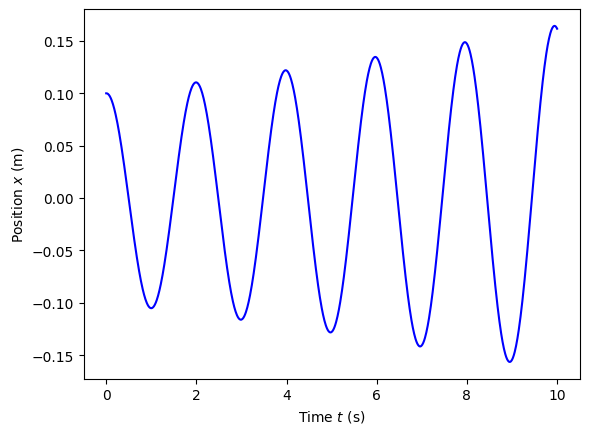

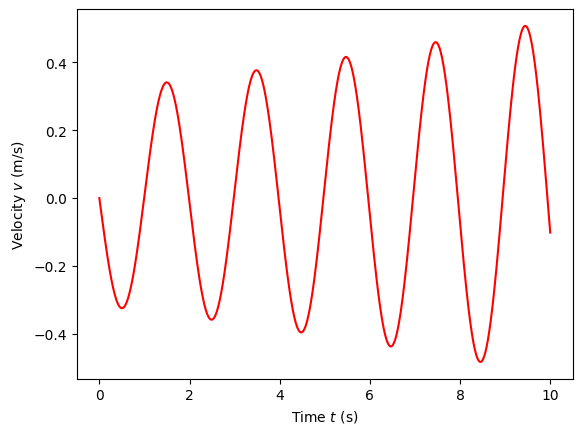

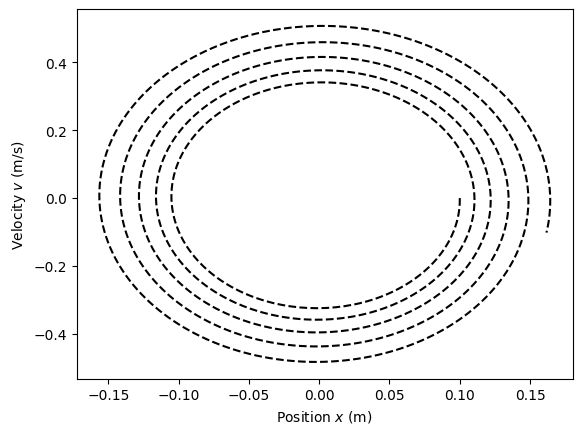

0.0 0.05000000000000001
10.0 0.13584619661179415


In [1]:
import numpy as np
import matplotlib.pyplot as plt
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
h = (t2-t1)/N
x = np.zeros(N+1)
v = np.zeros(N+1)
m = 1.0
k = 10.0
x[0] = 0.1
v[0] = 0.0
def a(x):
    return -k*x/m
for i in range(N):
    v[i+1] = v[i] + a(x[i]) * h
    x[i+1] = x[i] + v[i] * h
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.show()
print(t[0],1/2*k*x[0]**2+1/2*m*v[0]**2)
print(t[-1],1/2*k*x[-1]**2+1/2*m*v[-1]**2)

We probably expected to see oscillations with a constant amplitude, but rather we observe that the amplitude increases. The method used is very simple, and we need to improve the method: 

>$x(t+\Delta t)\approx x(t)+v(t)\Delta t$
>
>$v(t+\Delta t)\approx v(t)+a(t)\Delta t$

A simple improvement is to reorder the calculation and use the new value of the velocity as soon as it is calculated.

>$v(t+\Delta t)\approx v(t)+a(t)\Delta t$
>
>$x(t+\Delta t)\approx x(t)+v(t+\Delta t)\Delta t$

This modified method is called Euler-Cromer's method.

The loop used is now changed to 
```python
for i in range(N):
    v[i+1] = v[i] + a(x[i]) * h
    x[i+1] = x[i] + v[i+1] * h
```
where we see that the newly calculated velocity is used right away.

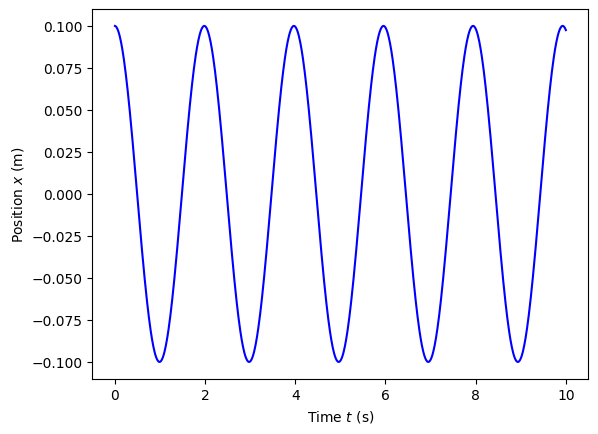

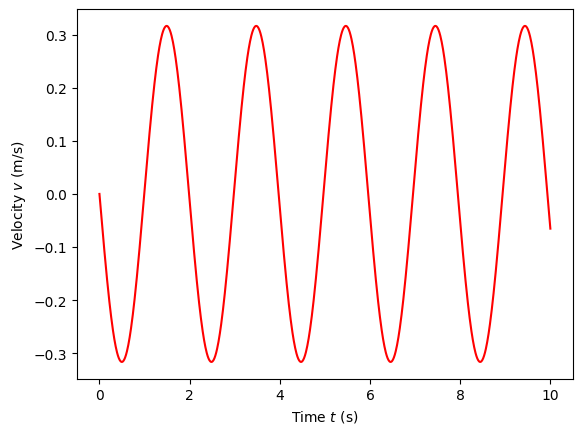

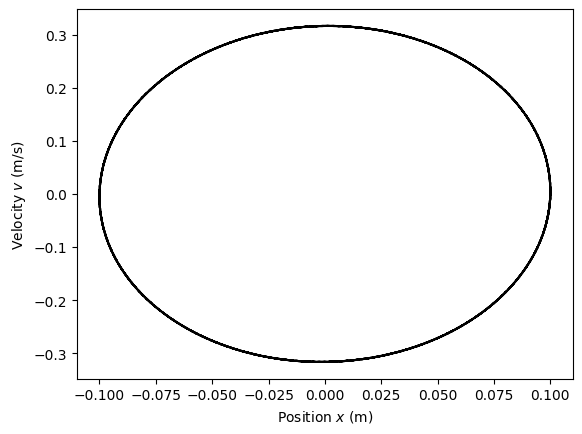

Energy = 0.0 0.05000000000000001
Energy = 10.0 0.0496813124398407


In [2]:
import numpy as np
import matplotlib.pyplot as plt
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
h = (t2-t1)/N
x = np.zeros(N+1)
v = np.zeros(N+1)
m = 1.0
k = 10.0
x[0] = 0.1
v[0] = 0.0
def a(x):
    return -k*x/m
for i in range(N):
    v[i+1] = v[i] + a(x[i]) * h
    x[i+1] = x[i] + v[i+1] * h
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.show()
print('Energy =',t[0],1/2*k*x[0]**2+1/2*m*v[0]**2) # print the mechanical energy at the start
print('Energy =',t[-1],1/2*k*x[-1]**2+1/2*m*v[-1]**2) # print the mechanical enerby at the end

This was an improvement, the amplitude of both position and velocity seems to be constant. This is still a very simple algorithm and we normally will use more advanced methods that are available in Python, specifically in *scipy*. 
To use the method in *scipy* called *solve_ivp* (solve initial value problem) you need to program a function that computes the values of the time derivatives of position and velocity in the equation of motion $m\ddot x=F(t,x,v)$ where $F$ reprents the sum of all the forces acting on the object; it is possible that the forces depend on time, position, and velocity, hence these are arguments to the function. The state of the system, y, contains x and v, and can be extracted by
```python
    x,v = y
```
which is shorter than x = y[0] and v = y[1]. Using descriptive names for variables makes the code easier to read. 

we rewrite like earlir the second order differential equation to two first order differential equations, $\dot x=v$ and $\dot v=F(t,x,v)/m$.
The function receives the current time, $t$ and an array $y$ that containt the positon and velocity, $y=\left[x,v\right]$. 
The first step is to put position and velocit in variable named *x* and *v*.
The next step is to return an array with the time derivatives of position and velocity in a array.
```python
def f(t,y):
    x,v = y
    return [v,-k*x/m]
```
Now you can call the *solve_ivp* method that receives teh function *f*, the time interval in which the solution is required, *[t1,t2]*, the initial value, *y0=[0.1,0.0]*, and the times at which the solution should be computed, *t_eval=t*. 
If you leave out the *t_eval* parameter the method will decide for itself at what times it obtains the solution.
```python
sol = integrate.solve_ivp(f,[t1,t2],[0.1,0.0],t_eval=t)
```
The order of the first three parameters is important unless you name them, then they can appear in different order. The following are equivalent.
```python
sol = integrate.solve_ivp(f,[t1,t2],[0.1,0.0],t_eval=t)
sol = integrate.solve_ivp(fun=f,t_span=[t1,t2],y0=[0.1,0.0],t_eval=t)
sol = integrate.solve_ivp(fun=f,y0=[0.1,0.0],t_span=[t1,t2],t_eval=t)
sol = integrate.solve_ivp(t_span=[t1,t2],fun=f,y0=[0.1,0.0],t_eval=t)
sol = integrate.solve_ivp(t_span=[t1,t2],y0=[0.1,0.0],fun=f,t_eval=t)
sol = integrate.solve_ivp(y0=[0.1,0.0],fun=f,t_span=[t1,t2],t_eval=t)
sol = integrate.solve_ivp(y0=[0.1,0.0],t_span=[t1,t2],fun=f,t_eval=t)
```

*solve_ivp* returns a structre that we for now save in a variable, *sol*. We are mainly interested in the times at which the solution has been computed and the solution values,  returner en struktur som vi her gemmer i en en variable, sol. Vi er interesseret i de tidspunkter løsningen er beregnet til, *sol.t* and the solutions that are in *sol.y*, where we can get the positions and velocities from *sol.y[0]* and *sol.y[1]*. 
We can then plot the solutions from these variables.
```python
t = sol.t
x = sol.y[0]
v = sol.y[1]
```


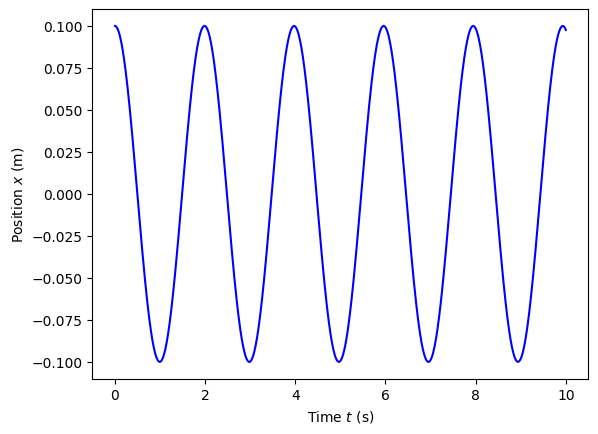

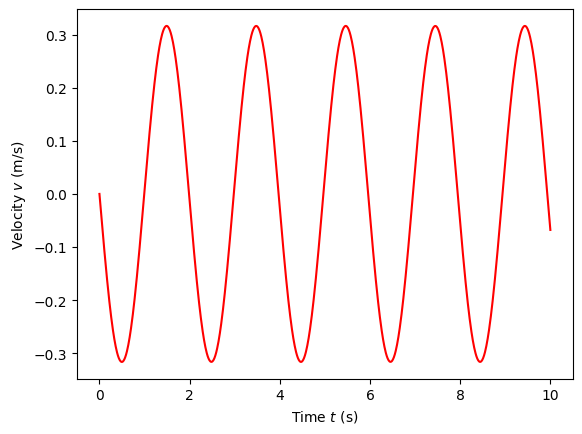

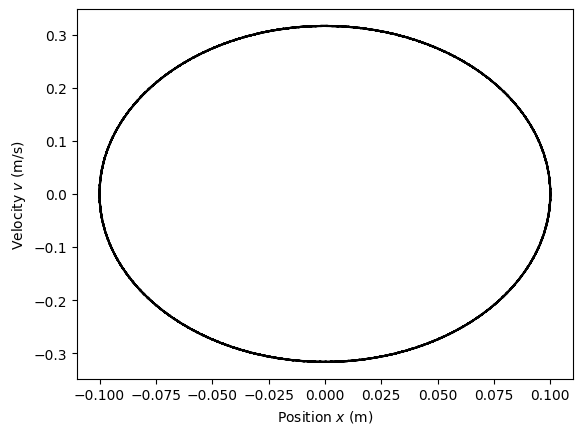

0.0 0.05000000000000001
10.0 0.04996689211140636


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
m = 1.0
k = 10.0
d = 0.0
def f(t,y):
    x,v = y
    return [v,-k*x/m-d*v/m]
sol = solve_ivp(f,[t1,t2],y0=[0.1,0.0],t_eval=t)
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.show()
print(t[0],1/2*k*x[0]**2+1/2*m*v[0]**2)
print(t[-1],1/2*k*x[-1]**2+1/2*m*v[-1]**2)

The order of parameters in calling *solve_ivp* is important if you do not use the name of the formal parameters.
The formal names for the first three parameters (that are required) are *fun*, *t_span*, and *y0*.
If you do not use the formal names of the parameters they must be in the correct order as in the first line below.
If you use the formal names you can swap the parameters as you like as shown in lines two and three.
```python
sol = solve_ivp(f,[t1,t2],[0.1,0.0])
sol = solve_ivp(fun=f,t_span=[t1,t2],y0=[0.1,0.0])
sol = solve_ivp(fun=f,y0=[0.1,0.0],t_span=[t1,t2])
```

## Why do we expect an ellipse?

Conservation of mechanical energy shows that the geometric form of the orbit is an ellipse, as the calculations show below.

The first expression is for the mechanical energy, that is the sum of the kinetic and potentiel energies.
This expression is diffenrentiated with respect to time and it is shown that the expression is zero, hence the mechanical energi is constant, or conserved.

Next we manipulate the expression for the mechanical energi and show that it can be rewritten as an ellipse in the $xv$-plane.

In [4]:
import sympy as sp
g,k,m,t = sp.symbols("g,k,m,t")
x = sp.Function('x')(t)
v = sp.Function('v')(t)
a = sp.Function('a')(t)
E = sp.Rational(1,2)*m*v**2+sp.Rational(1,2)*k*x**2
display(E)
dEdt = sp.diff(E,t)
display(dEdt)
dEdt = dEdt.subs({x.diff(t):v, v.diff(t):a})
display(dEdt)
dEdt = sp.factor(dEdt)
display(dEdt)
dEdt = dEdt.subs({})
dEdt = dEdt.subs({k*x:-m*a})
display(dEdt)
E0 = sp.symbols("E0")
E = sp.Eq(sp.Rational(1,2)*m*v**2+sp.Rational(1,2)*k*x**2,E0)
display(E)
E = sp.Eq(E.lhs/E0,E.rhs/E0)
display(E)
E = E.expand()
display(E)


k*x(t)**2/2 + m*v(t)**2/2

k*x(t)*Derivative(x(t), t) + m*v(t)*Derivative(v(t), t)

k*v(t)*x(t) + m*a(t)*v(t)

(k*x(t) + m*a(t))*v(t)

0

Eq(k*x(t)**2/2 + m*v(t)**2/2, E0)

Eq((k*x(t)**2/2 + m*v(t)**2/2)/E0, 1)

Eq(k*x(t)**2/(2*E0) + m*v(t)**2/(2*E0), 1)

## Determining maxima and minima of solutions
It is often required to determine maxima and minima of solutions, such as for the position.
In principle these could be found from the data generated for the solution, however, this will not always give a sufficiently accurate determination.
Instead we use so-called events that are points along the solution that we want to locate accurately.
For instance to find a zero for the velocity is an event where the solution satisfies $v(t)=0$.
The solve_ivp method can have several registered events that it searches for and locates during integration.
You define a function that is zero at the event, and changes sign going from positive to negative or vice versa.
Such a function can be defined as
```python
def zero(t,y):
    x,v = y
    return v
```
When solve_ivp detects that the function changes sign it locates the point accurately.

If you are only interested in the zeros where the velocity changes from positive to negative this 
can be achieved by setting the direction flag:
```python
zero.direction = -1
```
If you set the flag to +1 you will find zeros where the velocity changes from negative to positive only.



### Maxima
To use events to find maxima for $x(t)$ we define a function that has zeros there which is where the velocity is zero.
To catch only maxima the velocity goes from positive to negative so the direction flag should be set to -1.
```python
def maxima(t,y):
    x,v = y
    return v
maxima.direction = -1
```

### Minima
For minima we can use the same function as above but setting the direction flag to +1 since for minima
the velocity goes from negative to positive.
```python
def minima(t,y):
    x,v = y
    return v
minima.direction = 1
```

In the example below we analyse a damped oscillator and determine firste the maxima and then the minima. 
Note the we give solve_ivp an extra paramter events=[maxima] which may contain more than one event type.
Upon return the times of the events can be found in sol.t_events[0] and with different index if there are more events registered. To get the values of $x$ we have to use the command 
```python
sol.y_events[0][:,[0]] 
```
that takes the first event and the for all row values and only column 1, which is the $x$ values.
The $v$ values could be found by 
```python
sol.y_events[0][:,[1]]
```
but in our case they are all zero (or close to zero).
Both $x$ and $v$ values are printed out at the end of the code below.
In addition the maximum value is located by the np.max function.

The maxima are also plotted in the figure with the command
```python
plt.plot(sol.t_events[0],sol.y_events[0][:,[0]],'kx')
```
that plots a + at each maxima.

<Figure size 600x500 with 0 Axes>

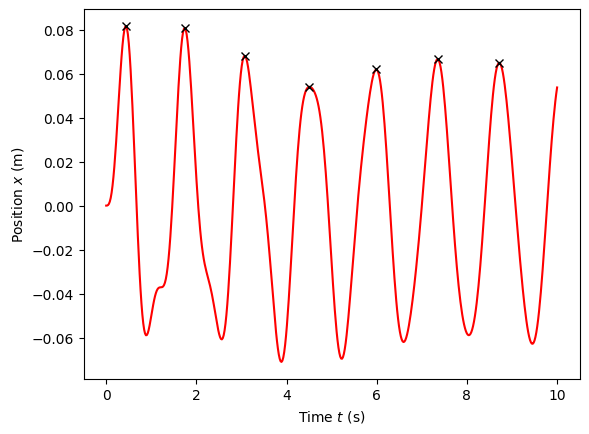

[[0.08172433]
 [0.08081977]
 [0.06814989]
 [0.0540518 ]
 [0.06192316]
 [0.0666717 ]
 [0.06497939]]
[[-7.80625564e-17]
 [-1.14491749e-16]
 [ 3.53883589e-16]
 [-1.09721260e-16]
 [-5.79397641e-16]
 [-6.97358837e-16]
 [ 3.57353036e-16]]
max x-value = 0.0817243288139062


In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 0.100
b = 0.050
k = 10.0
A = 0.5
omega = 4.5
t = np.linspace(0,10.0,500)
def f(t,y):
    x,v = y
    return [v,(A*np.sin(omega*t)-k*x-b*v)/m]
def maxima(t,y):
    x,v = y
    return v
maxima.direction = -1
def minima(t,y):
    x,v = y
    return v
minima.direction = 1
sol = solve_ivp(f,[t[0],t[-1]],[0.0,0.0],t_eval=t,events=[maxima],rtol=1e-8,atol=1e-8)
#display(sol)
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,sol.y[0],'r-')
plt.plot(sol.t_events[0],sol.y_events[0][:,[0]],'kx')
plt.show()
print(sol.y_events[0][:,[0]])
print(sol.y_events[0][:,[1]])
print('max x-value =',np.max(sol.y_events[0][:,[0]]))

<Figure size 600x500 with 0 Axes>

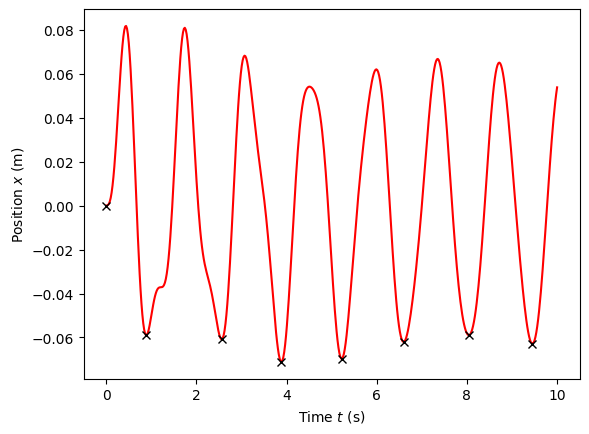

In [6]:
sol = solve_ivp(f,[t[0],t[-1]],[0.0,0.0],t_eval=t,events=[minima],rtol=1e-8,atol=1e-8)
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,sol.y[0],'r-')
plt.plot(sol.t_events[0],sol.y_events[0][:,0],'kx')
plt.show()

## Determining the period of a nonlinear oscillation
We consider a nonlinear oscillator with a nonlinear spring element.

>$m\ddot x=-k_1x+k_3x^3$

We use the parameter values and initial conditions below. 
```python
m = 0.5
k1 = 10.0
k3 = 3.7
x0 = 0.8
v0 = 0.0
```
We are going to plot the spring force as a function of extension for the nonlinear spring together with a linear spring ($k_3$=0).
Next we till simulate the equations of motion with the given parameter values and the initial conditions, and 
make time and phase plots.
Finally, we will determine the period of the nonlinear oscillation of the system.

<Figure size 600x500 with 0 Axes>

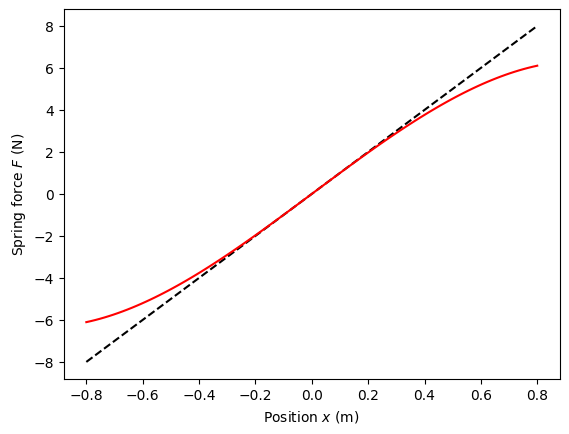

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 0.5
k1 = 10.0
k3 = 3.7
x0 = 0.8
v0 = 0.0
x = np.linspace(-x0,x0,100)
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Spring force $F$ (N)')
plt.plot(x,k1*x,'k--')
plt.plot(x,k1*x-k3*x**3,'r-')
plt.show()

We notice that the spring force deviation from the linear (Hooke's law) from around
$x=0.2$, and since our initial condition is $x_0=0.8$ we are well into the nonlinear regime.

<Figure size 600x500 with 0 Axes>

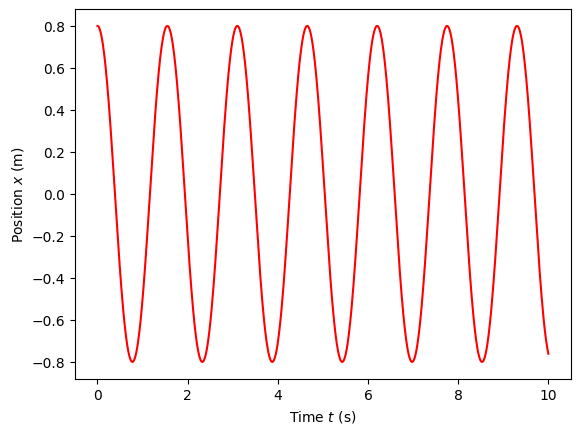

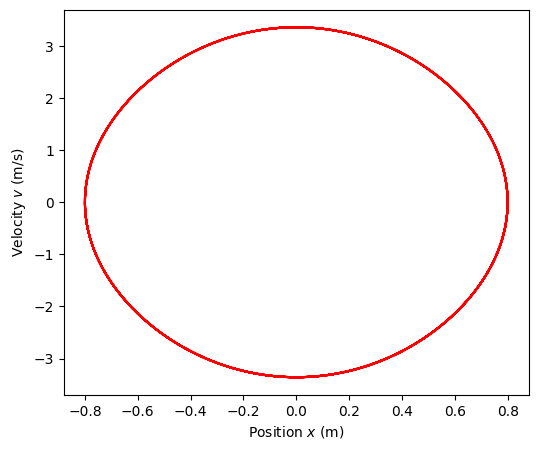

In [8]:
t = np.linspace(0,10.0,1000)
def f(t,y):
    x,v = y
    return [v,(-k1*x+k3*x**3)/m]
sol = solve_ivp(f,[t[0],t[-1]],[x0,v0],t_eval=t,rtol=1e-8,atol=1e-8)
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,sol.y[0],'r-')
plt.show()
plt.figure(figsize=(6,5))
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(sol.y[0],sol.y[1],'r-')
plt.show()

The time evolution of the position is oscillatory but it is not so clear how nonlinear (non-sinusoidal)
the oscillations are. The phase plot more clearly shows that we are in a very nonlinear regime.


Next we calculate all maxima with an event as earlier, and plot the result.

<Figure size 600x500 with 0 Axes>

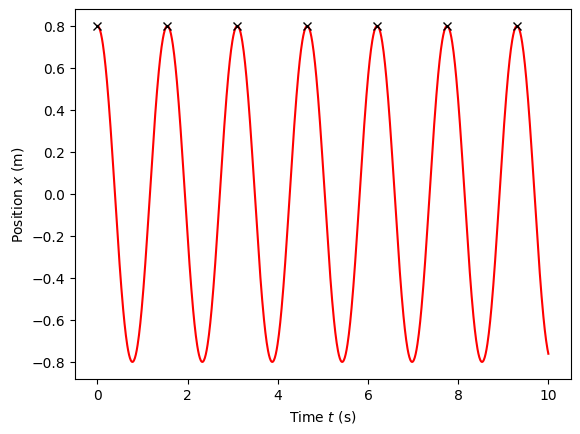

In [9]:
def maxima(t,y):
    x,v = y
    return v
maxima.direction = -1
sol = solve_ivp(f,[t[0],t[-1]],[x0,v0],t_eval=t,events=[maxima],rtol=1e-8,atol=1e-8)
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,sol.y[0],'r-')
plt.plot(sol.t_events[0],sol.y_events[0][:,0],'kx')
plt.show()


The x symbols are the maxima, and we see that the distance (in time) between the points is the period of the oscillation.

We select the times and print them.

In [10]:
T = sol.t_events[0]
print(T)

[0.         1.55076597 3.10153192 4.65229785 6.20306377 7.75382967
 9.30459555]


We want to compute the distance between the times, and do it by selecting an array of
all but the first point, and then selcting all but the last point, and then computing the 
different. T[0:-1] returns all elements apart from th elast (the selction is inclusive for the first element and
exclusive for the last element). T[1:] return all elements from the second to the last.

In [11]:
print(T[0:-1]) # does not include last element T[-1]
print(T[1:]) # include all but the first element

[0.         1.55076597 3.10153192 4.65229785 6.20306377 7.75382967]
[1.55076597 3.10153192 4.65229785 6.20306377 7.75382967 9.30459555]


Now we compute the difference between the arrays and compute mean, standard deviation, and standard deviation of the mean.

In [12]:
DT = T[1:]-T[0:-1]
print(DT)
DTm = np.mean(DT)
DTstd = np.std(DT,ddof=1)
DTsdom = DTstd / np.sqrt(np.size(DT))
from uncertainties import *
DTufloat = ufloat(DTm,DTsdom)
print(DTufloat)

[1.55076597 1.55076595 1.55076593 1.55076591 1.5507659  1.55076588]
1.550765925+/-0.000000013


Note that we have computed the period with a very small uncertainty.

## Find the maximum point an object

>$m\dot v=-kv-mg$


> $\dot x=v$

> $\dot v= \frac{-kv-mg}{m}$

Parameters and initial conditions are:
```python
m = 0.200
k = 0.3
g = 9.82
x0 = 2.0
v0 = 10.0
```
We modify the event by declaring it to be terminal, that is, the simulation should stop when the event has been located.
```python
def maxima(t,y):
    x,v = y
    return v
maxima.direction = -1 # find maximum
maxima.terminal = True # stop when reaching maximum
```

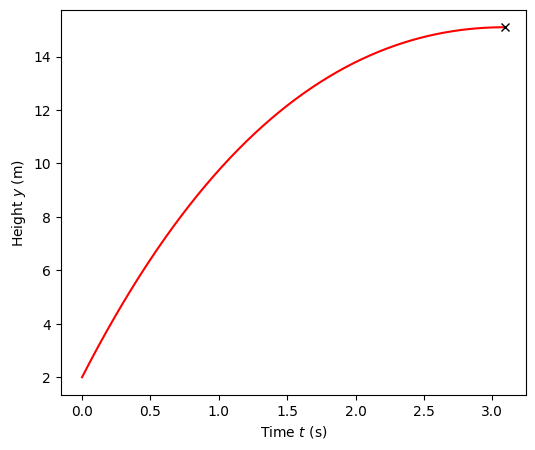

top point = 15.099143517752578


In [13]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 0.200
k = 0.3
g = 9.82
x0 = 2.0
v0 = 10.0
t = np.linspace(0,10.0,500)
def f(t,y):
    x,v = y
    return [v,-m*g-k*v]
def maxima(t,y):
    x,v = y
    return v
maxima.direction = -1
maxima.terminal = True
sol = solve_ivp(f,[t[0],t[-1]],[x0,v0],t_eval=t,events=[maxima],rtol=1e-8,atol=1e-8)
plt.figure(figsize=(6,5))
plt.xlabel('Time $t$ (s)')
plt.ylabel('Height $y$ (m)')
plt.plot(sol.t,sol.y[0],'r-')
plt.plot(sol.t_events[0],sol.y_events[0][:,0],'kx')
plt.show()
print('top point =',sol.y_events[0][:,0][0])

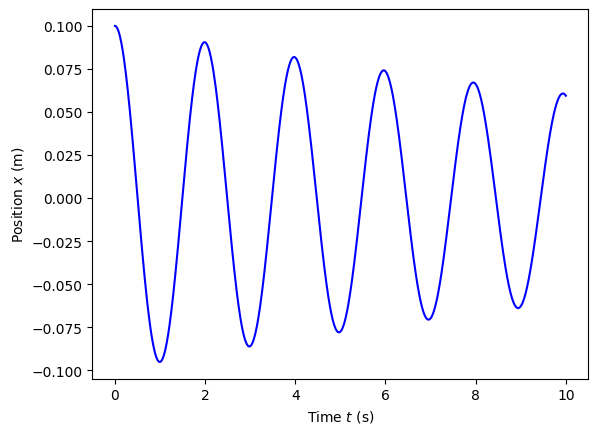

In [14]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
m = 1.0
k1 = 10.0
k3 = 0.5
b = 0.1
def f(t,y):
    x,v = y
    return [v,(-b*v-k1*x+k3*x**3)]
sol = solve_ivp(f,[t1,t2],y0=[0.1,0.0],t_eval=t)
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()

#### Extra examples

In [15]:
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
m = 1.0
k = 10.0
def f(t,y):
    x,v = y
    return [v,-k*x/m]
sol = solve_ivp(f,[t1,t2],y0=[0.1,0.0])
display(sol)
t = sol.t
x = sol.y[0]
v = sol.y[1]

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.901e-04 ...  9.864e+00  1.000e+01]
        y: [[ 1.000e-01  1.000e-01 ...  9.770e-02  9.764e-02]
            [ 0.000e+00 -9.901e-04 ...  6.699e-02 -6.780e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 218
     njev: 0
      nlu: 0

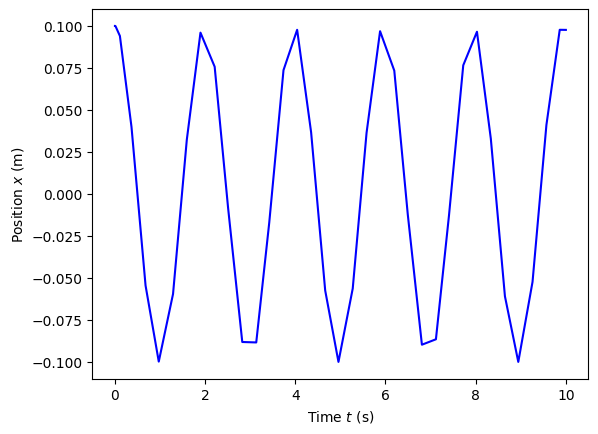

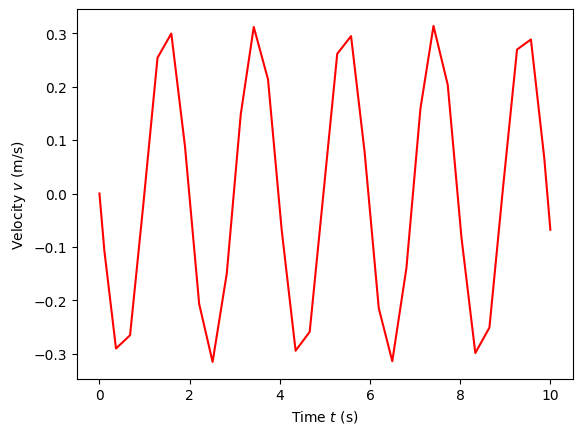

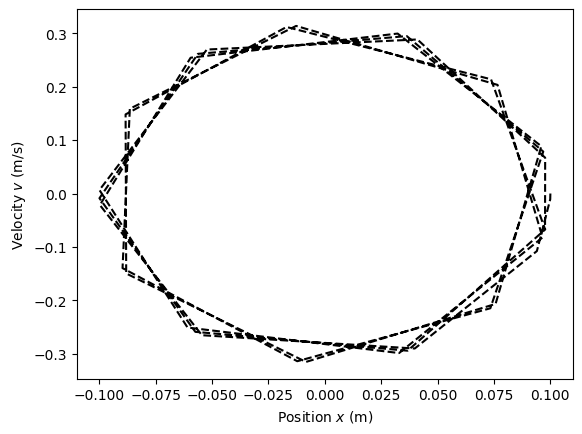

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
m = 1.0
k = 10.0
def f(t,y):
    x,v = y
    return [v,-k*x/m]
sol = solve_ivp(f,[t1,t2],y0=[0.1,0.0])
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.show()
u = np.copy(sol.y[0])
w = np.copy(sol.y[1])

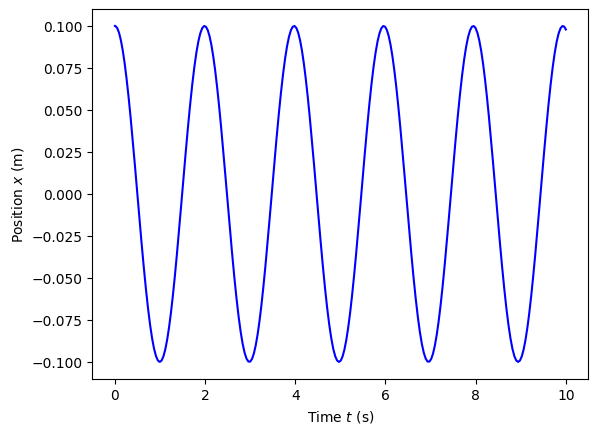

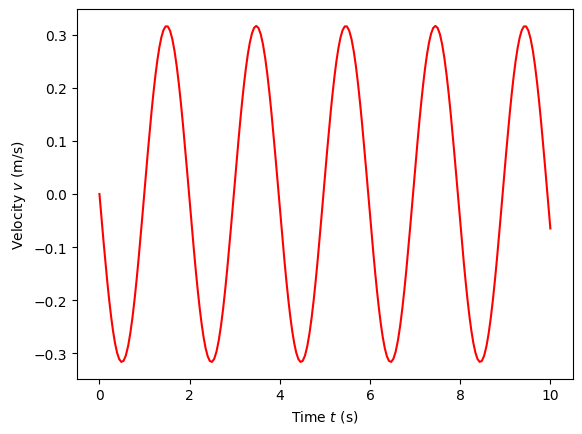

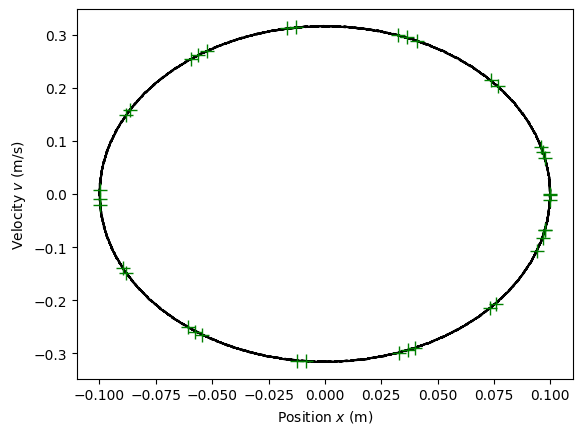

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
m = 1.0
k = 10.0
def f(t,y):
    x,v = y
    return [v,-k*x/m]
sol = solve_ivp(f,[t1,t2],y0=[0.1,0.0],atol=1e-8,rtol=1e-8)
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.plot(u,w,'g+',markersize=10)
plt.show()

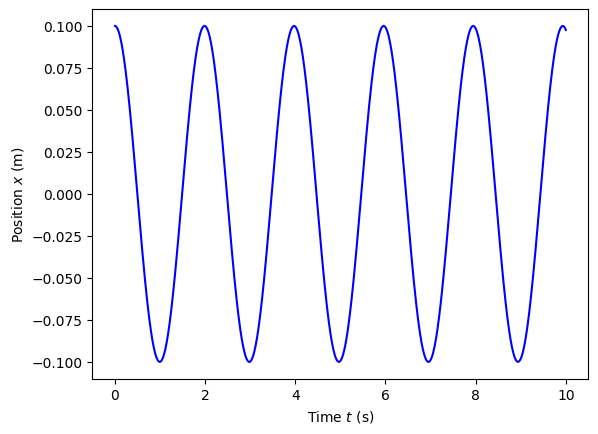

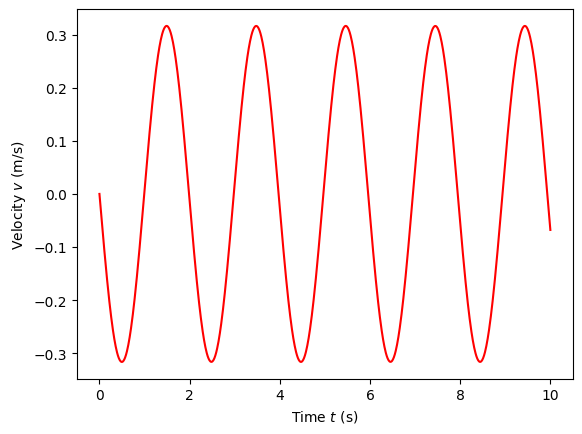

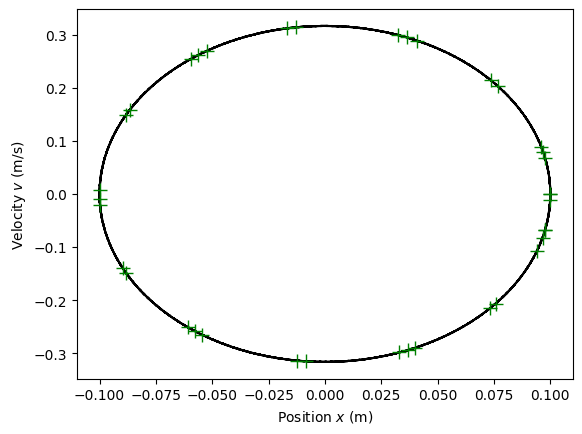

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
m = 1.0
k = 10.0
def f(t,y):
    x,v = y
    return [v,-k*x/m]
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[0.1,0.0])
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.plot(u,w,'g+',markersize=10)
plt.show()

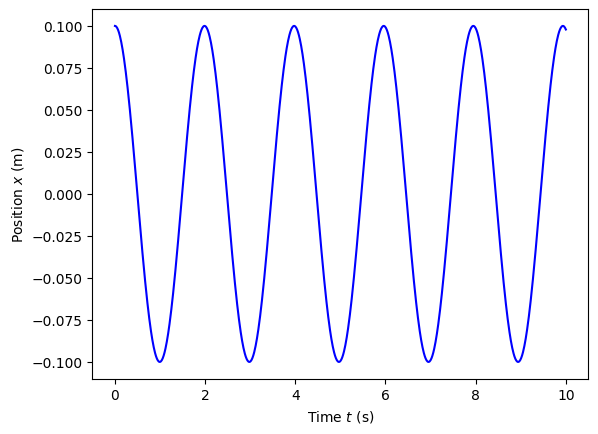

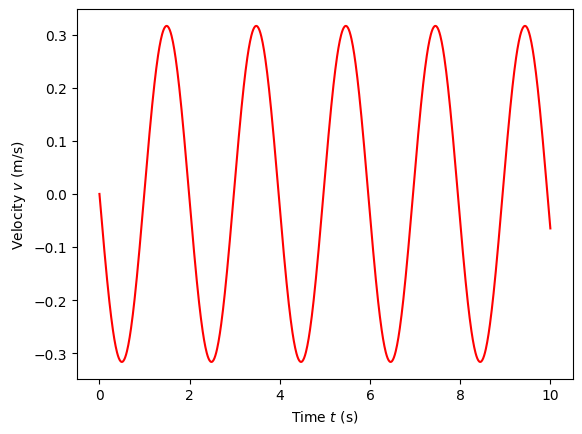

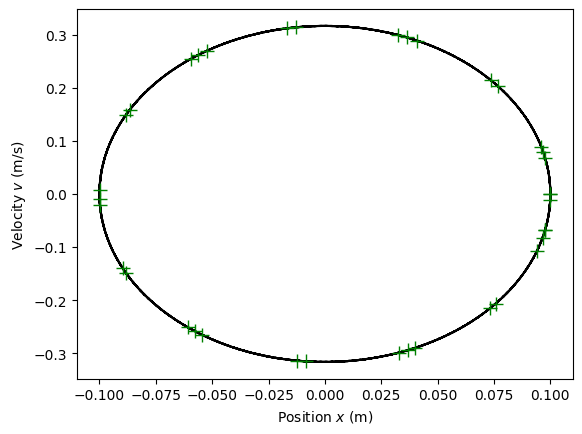

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
t1 = 0.0
t2 = 10.0
N = 1000
t = np.linspace(t1,t2,N+1)
m = 1.0
k = 10.0
def f(t,y):
    x,v = y
    return [v,-k*x/m]
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[0.1,0.0],atol=1e-8,rtol=1e-8)
t = sol.t
x = sol.y[0]
v = sol.y[1]
plt.figure()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.plot(t,x,'b-')
plt.show()
plt.xlabel('Time $t$ (s)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(t,v,'r-')
plt.show()
plt.xlabel('Position $x$ (m)')
plt.ylabel('Velocity $v$ (m/s)')
plt.plot(x,v,'k--')
plt.plot(u,w,'g+',markersize=10)
plt.show()

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  6.176e-03 ...  2.142e+00  2.237e+00]
        y: [[ 1.000e+01  1.000e+01 ...  5.633e-01 -8.882e-16]
            [ 0.000e+00 -6.035e-02 ... -5.938e+00 -5.966e+00]]
      sol: None
 t_events: [array([ 2.237e+00])]
 y_events: [array([[-8.882e-16, -5.966e+00]])]
     nfev: 182
     njev: 0
      nlu: 0

2.2368885363255058


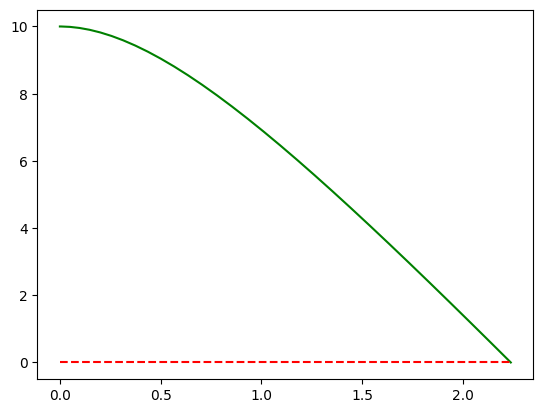

In [20]:
import numpy as np
from scipy.integrate import solve_ivp
g = 9.82
m = 0.25
k = 0.4
h = 10.0
def f(t,z):
    y,v = z
    return [v,-g-k*v/m]
def hit_ground(t,z):
    y,v = z
    return y
hit_ground.direction = -1
hit_ground.terminal = True
sol = solve_ivp(f,t_span=[0,10],y0=[h,0],events=[hit_ground],atol=1e-8,rtol=1e-8)
display(sol)
print(sol.t_events[0][0])
import matplotlib.pyplot as plt
plt.figure()
plt.plot(sol.t,sol.y[0],'g-')
plt.plot([sol.t[0],sol.t[-1]],[0,0],'r--')
plt.show()
for h in np.linspace(0.1,10,100):
    sol = solve_ivp(f,t_span=[0,10],y0=[h,0],events=[hit_ground],atol=1e-8,rtol=1e-8)

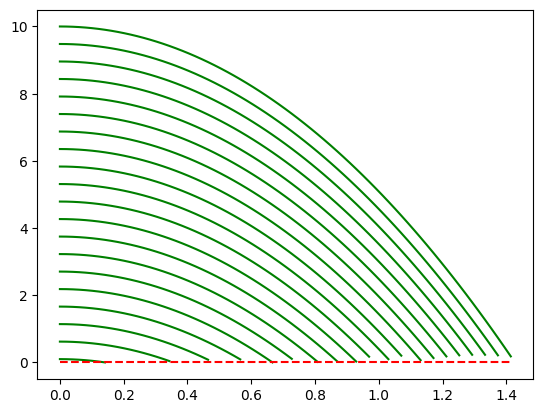

In [21]:
k = 0
t_eval = np.linspace(0,2,100)
plt.figure()
for h in np.linspace(0.1,10,20):
    sol = solve_ivp(f,t_span=[0,10],y0=[h,0],t_eval=t_eval,events=[hit_ground],atol=1e-8,rtol=1e-8)
    plt.plot(sol.t,sol.y[0],'g-')
plt.plot([sol.t[0],sol.t[-1]],[0,0],'r--')
plt.show()

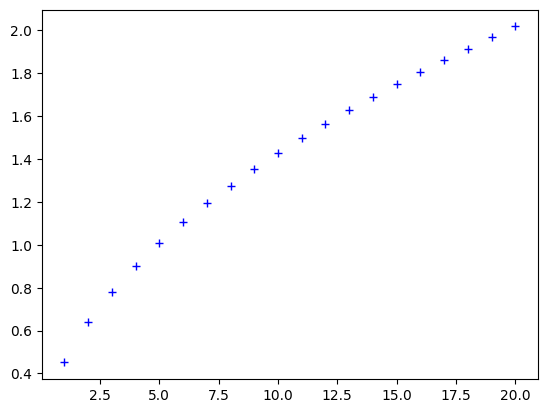

In [22]:
h_values = []
t_values = []
for h in np.linspace(1,20,20):
    sol = solve_ivp(f,t_span=[0,10],y0=[h,0],events=[hit_ground],atol=1e-8,rtol=1e-8)
    h_values.append(h)
    t_values.append(sol.t_events[0][0])
plt.figure()
plt.plot(h_values,t_values,'b+')
plt.show()

In [23]:
from scipy.optimize import curve_fit
def fit(t,A,B):
    return A*t**B
param,cov = curve_fit(fit,h_values,t_values)
display(param)
display(np.sqrt(np.diag(cov)))

array([0.45129368, 0.5       ])

array([7.83131354e-17, 6.75349626e-17])

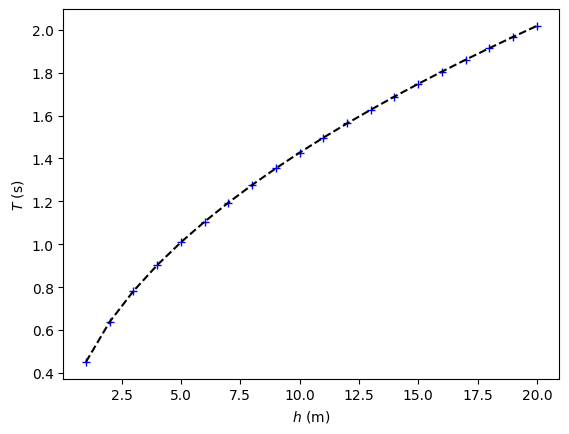

In [24]:
plt.figure()
plt.plot(h_values,t_values,'b+')
plt.plot(h_values,fit(h_values,*param),'k--')
plt.xlabel('$h$ (m)')
plt.ylabel('$T$ (s)')
plt.show()

In [25]:
h_values = np.array(h_values)
t_values = np.array(t_values)
print(h_values)
print(t_values)
pi_1 = m**2*g/(h_values*k**2)
pi_2 = t_values/(m/k)
plt.figure()
plt.plot(pi_1,pi_2,'b+')
plt.plot(h_values,fit(h_values,*param),'k--')
plt.xlabel('$h$ (m)')
plt.ylabel('$T$ (s)')
plt.show()

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
[0.45129368 0.63822565 0.78166359 0.90258736 1.00912335 1.10543925
 1.19401085 1.27645129 1.35388105 1.42711593 1.49677181 1.56332717
 1.62716251 1.68858634 1.74785292 1.80517473 1.86073152 1.91467694
 1.96714356 2.0182467 ]


C:\Users\Carsten Knudsen\AppData\Local\Temp\ipykernel_24180\3888813178.py:5: RuntimeWarning: divide by zero encountered in divide
  pi_1 = m**2*g/(h_values*k**2)


ZeroDivisionError: float division by zero

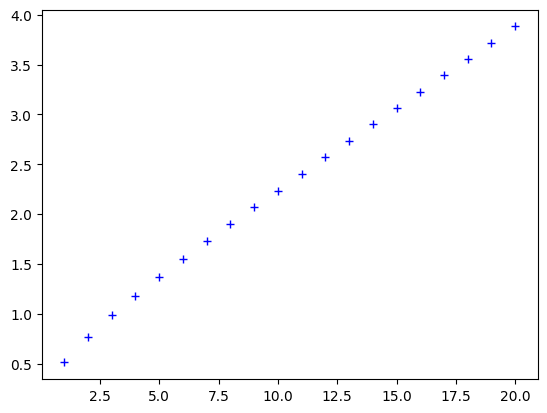

In [13]:
k = 0.4
h_values = []
t_values = []
for h in np.linspace(1,20,20):
    sol = solve_ivp(f,t_span=[0,10],y0=[h,0],events=[hit_ground],atol=1e-8,rtol=1e-8)
    h_values.append(h)
    t_values.append(sol.t_events[0][0])
plt.figure()
plt.plot(h_values,t_values,'b+')
plt.show()

In [26]:
h_values = np.array(h_values)
t_values = np.array(t_values)
from scipy.optimize import curve_fit
def fit(t,A,B):
    return A*t**B
param,cov = curve_fit(fit,h_values,t_values)
display(param)
display(np.sqrt(np.diag(cov)))

array([0.41078282, 0.74409693])

array([0.01123085, 0.0103219 ])

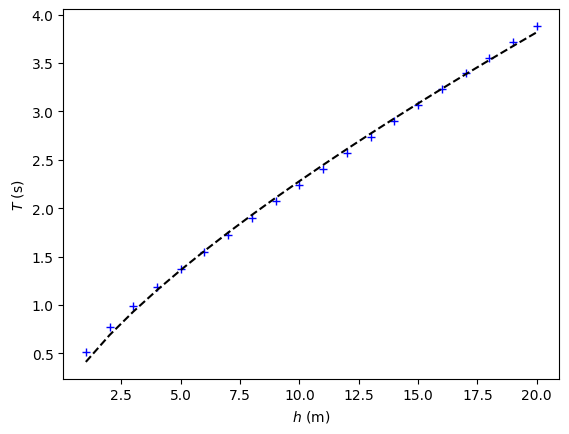

In [27]:
plt.figure()
plt.plot(h_values,t_values,'b+')
plt.plot(h_values,fit(h_values,*param),'k--')
plt.xlabel('$h$ (m)')
plt.ylabel('$T$ (s)')
plt.show()

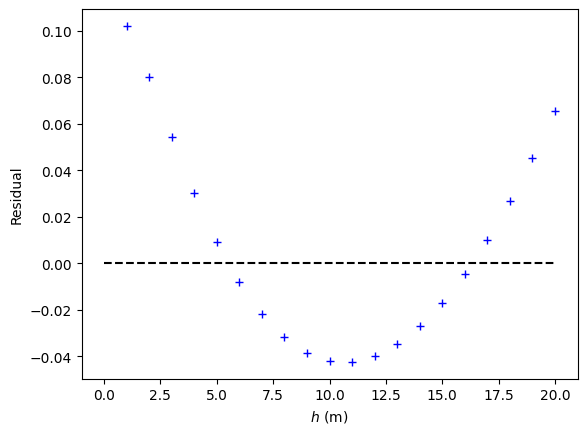

0.045711702403701454
0.10200843106925883


In [38]:
plt.figure()
plt.plot(h_values,t_values-fit(h_values,*param),'b+')
plt.plot([0,20],[0,0],'k--')
plt.xlabel('$h$ (m)')
plt.ylabel('Residual')
plt.show()
print(np.std(t_values-fit(h_values,*param),ddof=2))
print(max(t_values-fit(h_values,*param)))